# Zadanie domowe 1

### Autor: Kacper Łączyński

## Zadanie 1: Wybór akcji i uzasadnienie

**Cel:** Wybór 5 powiązanych ze sobą spółek oraz uzasadnienie dokonanego wyboru.

Do poniższej analizy ryzyka wybrałem 5 spółek reprezentujących polski sektor bankowy, notowanych na Giełdzie Papierów Wartościowych w Warszawie:

1. **PKO Bank Polski** (ticker: `PKO.WA`)
2. **Bank Pekao** (ticker: `PEO.WA`)
3. **Santander Bank Polska** (ticker: `SPL.WA`)
4. **mBank** (ticker: `MBK.WA`)
5. **Alior Bank** (ticker: `ALR.WA`)

### Uzasadnienie mojego wyboru:

Swój wybór opieram na trzech głównych powodach, dzięki którym powyższe spółki stanowią dla mnie spójną grupę analityczną:

* **Podatność na te same czynniki:** Wszystkie wybrane przeze mnie banki działają w Polsce, więc reagują na te same wydarzenia makroekonomiczne. Kiedy NBP zmienia stopy procentowe, rośnie inflacja albo waha się wartość złotego, wpływa to na wycenę tych spółek w bardzo zbliżony sposób.
* **Pewne i łatwe w obróbce dane:** Zdecydowałem się na giełdowych gigantów. Inwestorzy handlują ich akcjami codziennie, dzięki czemu nie napotkam na wykresach dni "bez transakcji". Oznacza to, że pobrane przeze mnie dane będą gęste, spójne i ułatwią mi proces ich czyszczenia.
* **Świetna baza do badania korelacji:** Przyjmuję założenie, że akcje firm z tego samego sektora powinny poruszać się w podobnym kierunku (np. gdy jeden polski bank rośnie, reszta zazwyczaj też). **Daje mi to jasną hipotezę badawczą, którą będę mógł łatwo zweryfikować w dalszej części mojego projektu**.

## Zadanie 2: Pobranie danych

**Źródło danych:** Yahoo Finance  
**Zakres czasowy:** Ostatnie 2 lata wstecz od dnia 10.04.2026r.   
**Format danych:** Dzienne ceny zamknięcia (kolumna `Close`) złączone z datami jako indeksem szeregu czasowego.

In [3]:
import yfinance as yf
import pandas as pd

tickers = ['PKO.WA', 'PEO.WA', 'SPL.WA', 'MBK.WA', 'ALR.WA']

dane_surowe = yf.download(tickers, start="2024-04-10", end="2026-04-11", threads=False)

ceny_zamkniecia = dane_surowe['Close']

display(ceny_zamkniecia.head())

[*********************100%***********************]  5 of 5 completed


Ticker,ALR.WA,MBK.WA,PEO.WA,PKO.WA,SPL.WA
Date,,,,,
2024-04-10,85.276596,711.799988,152.909348,53.144833,447.889984
2024-04-11,82.086800,695.400024,148.487198,51.602093,432.728271
2024-04-12,81.158127,687.200012,146.418106,51.247440,426.849213
2024-04-15,81.602280,683.799988,147.635208,51.584362,429.479340
2024-04-16,80.689743,670.599976,143.172501,49.527370,419.887177


## Zadanie 3: Sprawdzenie jakości i czyszczenie danych

--- ZADANIE 3: SPRAWDZENIE JAKOŚCI DANYCH ---

1. Brakujące dane przed czyszczeniem:
Ticker
ALR.WA    0
MBK.WA    0
PEO.WA    0
PKO.WA    0
SPL.WA    0
dtype: int64

2. Spójność dat kalendarza sesyjnego:
Data początkowa: 2024-04-10
Data końcowa: 2026-04-10
Liczba pobranych dni sesyjnych ogółem: 497


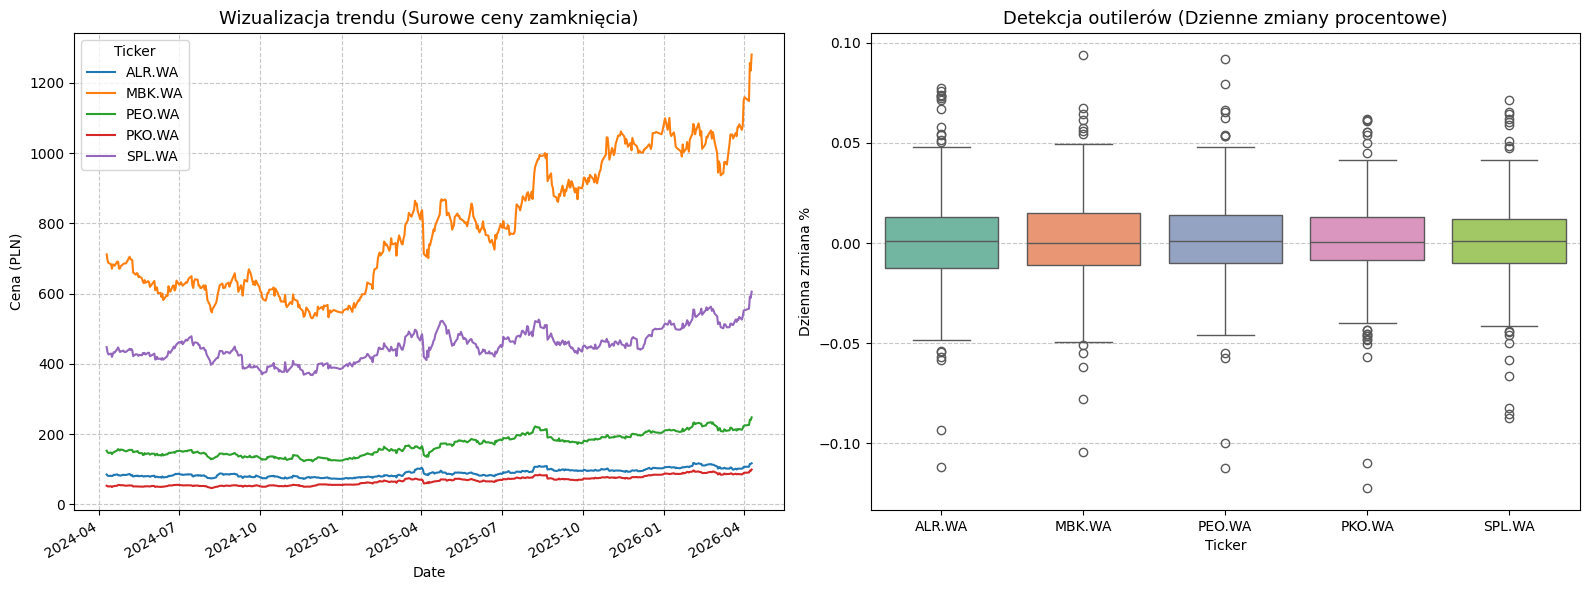

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ZADANIE 3: SPRAWDZENIE JAKOŚCI DANYCH ---\n")

# 1. SPRAWDZENIE BRAKUJĄCYCH DANYCH
print("1. Brakujące dane przed czyszczeniem:")
print(ceny_zamkniecia.isnull().sum())

# 2. SPRAWDZENIE SPÓJNOŚCI DAT
print("\n2. Spójność dat kalendarza sesyjnego:")
print(f"Data początkowa: {ceny_zamkniecia.index.min().date()}")
print(f"Data końcowa: {ceny_zamkniecia.index.max().date()}")
print(f"Liczba pobranych dni sesyjnych ogółem: {len(ceny_zamkniecia)}")

# 3. DETEKCJA OUTLIERÓW (WYKRES LINIOWY I PUDEŁKOWY)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ceny_zamkniecia.plot(ax=axes[0], linewidth=1.5)
axes[0].set_title("Wizualizacja trendu (Surowe ceny zamknięcia)", fontsize=13)
axes[0].set_ylabel("Cena (PLN)")
axes[0].grid(True, linestyle='--', alpha=0.7)

zmiany_procentowe = ceny_zamkniecia.pct_change().dropna()
sns.boxplot(data=zmiany_procentowe, palette="Set2", ax=axes[1])
axes[1].set_title("Detekcja outilerów (Dzienne zmiany procentowe)", fontsize=13)
axes[1].set_ylabel("Dzienna zmiana %")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
stopy_zwrotu.head()

Ticker,ALR.WA,MBK.WA,PEO.WA,PKO.WA,SPL.WA
Date,,,,,
2024-04-11,-0.038123,-0.023310,-0.029347,-0.029459,-0.034438
2024-04-12,-0.011378,-0.011862,-0.014032,-0.006897,-0.013679
2024-04-15,0.005458,-0.004960,0.008278,0.006553,0.006143
2024-04-16,-0.011246,-0.019493,-0.030694,-0.040693,-0.022588
2024-04-17,0.013717,0.018322,0.023524,0.036559,0.019340


## Zadanie 3: Sprawdzenie jakości i czyszczenie danych - Podsumowanie

Pobrany zbiór danych rynkowych poddałem weryfikacji pod kątem kompletności oraz występowania potencjalnych wartości odstających. Zrozumienie struktury danych jest kluczowe przed przystąpieniem do kwantyfikacji ryzyka.

### 1. Kompletność danych (Braki w szeregach czasowych)
W pierwszej kolejności zweryfikowałem ciągłość notowań dla wszystkich 5 banków w okresie od 10.04.2024 do 10.04.2026 (łącznie 497 dni sesyjnych).

* **Wynik weryfikacji:** Zbiór danych jest w 100% kompletny. Zidentyfikowano dokładnie **0 brakujących wartości (NaN)** dla każdej z analizowanych spółek.
* **Podejście analityczne:** W związku z brakiem luk, **celowo zrezygnowałem z aplikowania jakichkolwiek metod uzupełniania danych (w tym popularnego `forward-fill`).** Automatyczne stosowanie metody `ffill` bez wyraźnego uzasadnienia biznesowego jest błędem metodycznym w analizie ryzyka – w przypadku wystąpienia luki skopiowanie ceny z dnia poprzedniego generuje sztuczną, zerową stopę zwrotu. Prowadzi to do niedoszacowania historycznej zmienności instrumentu, co z kolei skutkuje błędnym, zbyt optymistycznym wyliczeniem miar takich jak Value at Risk (VaR).

### 2. Identyfikacja wartości odstających (Outlierów)
W celu zbadania struktury stóp zwrotu i identyfikacji anomalii cenowych, zastosowałem analizę wizualną:

* **Wykres liniowy (surowe ceny):** Potwierdził ciągłość notowań i brak błędów po stronie dostawcy danych.
* **Wykres pudełkowy (dla zmian procentowych):** Narzędzie to zidentyfikowało obserwacje znajdujące się poza standardowym przedziałem rozstępu ćwiartkowego. Dla badanego sektora bankowego są to dni o ekstremalnie wysokiej zmienności, sięgającej rzędu 10-12%.

**Decyzja metodyczna:** Wartości odstające **zostały świadomie zachowane w zbiorze danych**. W statystyce klasycznej outliery często traktuje się jako błędy pomiarowe podlegające usunięciu. Jednakże w analizie rynków finansowych te skrajne obserwacje reprezentują zjawisko tzw. **grubych ogonów (fat tails)** rozkładu, czyli rzeczywiste szoki rynkowe i realizację ryzyka ekstremalnego. Ich usunięcie doprowadziłoby do drastycznego wygładzenia rozkładu i fałszywego zaniżenia potencjalnych strat portfela w warunkach skrajnych (stress testing).

## Zadanie 4: Przygotowanie stóp zwrotu i statystyki opisowe

--- ZADANIE 4: LOGARYTMICZNE STOPY ZWROTU I STATYSTYKI ---

Statystyki opisowe logarytmicznych stóp zwrotu:


Ticker,ALR.WA,MBK.WA,PEO.WA,PKO.WA,SPL.WA
count,496.000000,496.000000,496.000000,496.000000,496.000000
mean,0.000639,0.001184,0.000973,0.001259,0.000608
std,0.022662,0.022080,0.020943,0.020292,0.020379
min,-0.118264,-0.110369,-0.119183,-0.130431,-0.091442
25%,-0.012297,-0.011084,-0.010202,-0.008657,-0.010072
50%,0.000954,0.000000,0.000913,0.000662,0.001116
75%,0.012744,0.014785,0.014000,0.012668,0.012105
max,0.074536,0.089911,0.087675,0.060132,0.068874


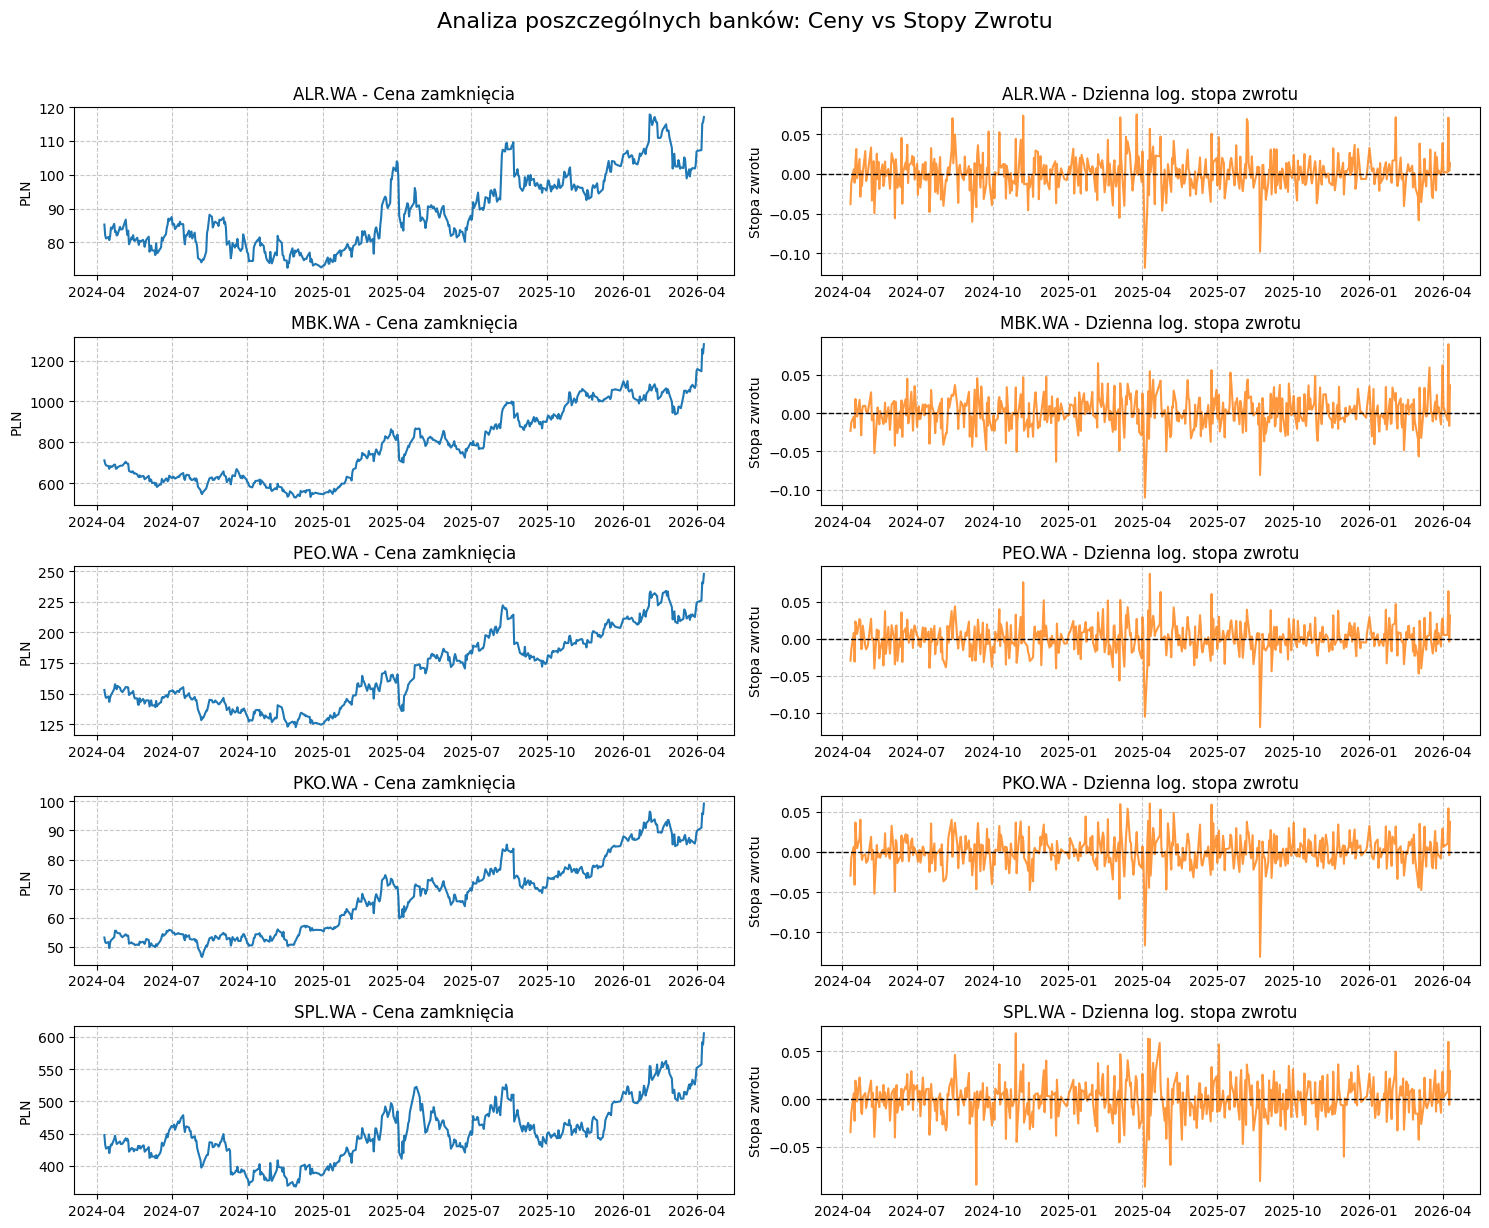

In [9]:
import numpy as np
import matplotlib.pyplot as plt

print("--- ZADANIE 4: LOGARYTMICZNE STOPY ZWROTU I STATYSTYKI ---\n")

stopy_zwrotu = np.log(ceny_zamkniecia / ceny_zamkniecia.shift(1)).dropna()

statystyki_opisowe = stopy_zwrotu.describe()
print("Statystyki opisowe logarytmicznych stóp zwrotu:")
display(statystyki_opisowe)

banki = ceny_zamkniecia.columns
fig, axes = plt.subplots(nrows=len(banki), ncols=2, figsize=(15, 12))
fig.suptitle('Analiza poszczególnych banków: Ceny vs Stopy Zwrotu', fontsize=16, y=1.02)

for i, bank in enumerate(banki):
    axes[i, 0].plot(ceny_zamkniecia.index, ceny_zamkniecia[bank], color='tab:blue')
    axes[i, 0].set_title(f'{bank} - Cena zamknięcia')
    axes[i, 0].set_ylabel('PLN')
    axes[i, 0].grid(True, linestyle='--', alpha=0.7)

    axes[i, 1].plot(stopy_zwrotu.index, stopy_zwrotu[bank], color='tab:orange', alpha=0.8)
    axes[i, 1].set_title(f'{bank} - Dzienna log. stopa zwrotu')
    axes[i, 1].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[i, 1].set_ylabel('Stopa zwrotu')
    axes[i, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Zadanie 4: Przygotowanie stóp zwrotu i statystyki opisowe - Podsumowanie

Analizując tabelę statystyk opisowych (obejmującą 496 dziennych obserwacji dla każdej spółki) oraz rozkłady stóp zwrotu, sformułowałem następujące wnioski dotyczące profilu ryzyka wybranego koszyka:

* **Zmienność:** Jako miarę historycznego ryzyka rynkowego przyjąłem odchylenie standardowe (`std`), które w zbadanej przeze mnie grupie okazało się wysoce homogeniczne. Ustaliłem, że największą zmiennością charakteryzuje się Alior Bank (**2,26%** dziennie), a najmniejszą PKO BP (**2,02%**). Różnicę na poziomie ok. 0,24 p.p. oceniam jako marginalną, co potwierdzają wygenerowane przeze mnie wykresy gęstości, na których rozkłady tych instrumentów są do siebie niezwykle zbliżone. Utwierdza mnie to w przekonaniu o ekspozycji badanych banków na dokładnie te same makroekonomiczne czynniki ryzyka.
* **Grube ogony:** Badając statystyki skrajne (`min`, `max`), zidentyfikowałem występowanie tzw. grubych ogonów rozkładu, typowych dla rynków finansowych. Mimo relatywnie niskiego średniego odchylenia zauważam, że instrumenty te są podatne na gwałtowne szoki:
    * Najgłębszy jednodniowy spadek odnotował PKO BP (**-13,04%**), co na wygenerowanym przeze mnie wykresie szeregu czasowego przyjmuje postać ostrego piku zmienności.
    * Najsilniejsze jednodniowe odbicie zaobserwowałem dla mBanku (**8,99%**).
* **Trend cenowy:** Obliczone przeze mnie średnie dzienne logarytmiczne stopy zwrotu (`mean`) dla wszystkich banków przyjmują wartości dodatnie i oscylują w granicach od **0,06%** do **0,12%**. Choć w ujęciu jednodniowym są to wartości niemal bliskie zera, to zauważam, że w ujęciu skumulowanym tłumaczą one wyraźny trend wzrostowy cen akcji, obserwowany przeze mnie na przestrzeni analizowanych dwóch lat.

**Mój wniosek metodyczny:** Jednorodne parametry rozkładu (zbliżone średnie, bardzo podobna zmienność oraz symetryczne reakcje na szoki) traktuję jako silny sygnał o systemowym powiązaniu tych spółek. Wskazuje mi to na wysokie prawdopodobieństwo występowania silnej korelacji dodatniej wewnątrz koszyka, co stanowi dla mnie punkt wyjścia do dalszej analizy struktury zależności i budowy macierzy korelacji.

## Zadanie 5: Korelacja między akcjami

--- ZADANIE 5: KORELACJA MIĘDZY AKCJAMI ---

Macierz korelacji Pearsona:


Ticker,ALR.WA,MBK.WA,PEO.WA,PKO.WA,SPL.WA
Ticker,,,,,
ALR.WA,1.000000,0.764955,0.822879,0.781045,0.762704
MBK.WA,0.764955,1.000000,0.796301,0.777154,0.778174
PEO.WA,0.822879,0.796301,1.000000,0.870554,0.814091
PKO.WA,0.781045,0.777154,0.870554,1.000000,0.801702
SPL.WA,0.762704,0.778174,0.814091,0.801702,1.000000


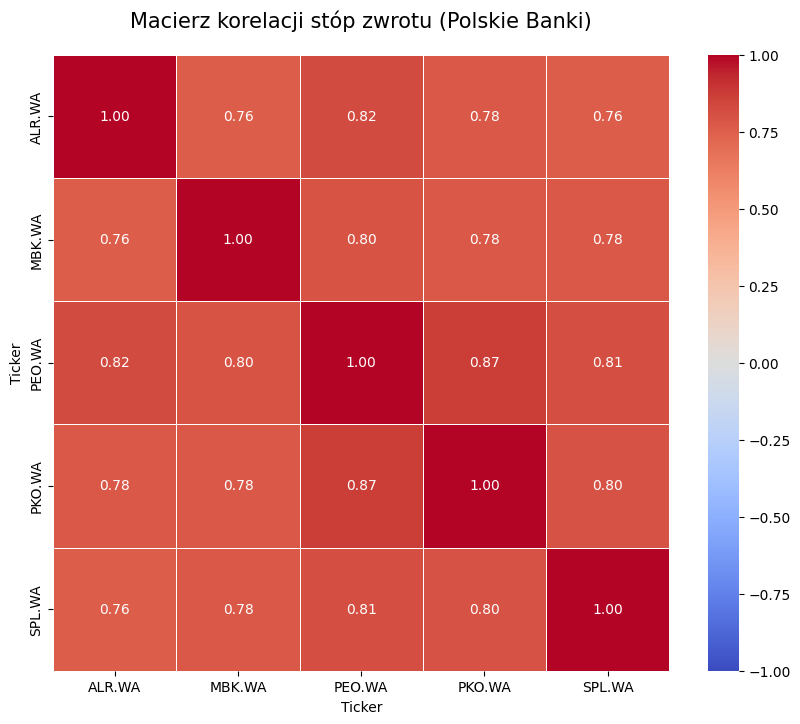

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- ZADANIE 5: KORELACJA MIĘDZY AKCJAMI ---\n")

korelacja = stopy_zwrotu.corr()

print("Macierz korelacji Pearsona:")
display(korelacja)

plt.figure(figsize=(10, 8))

sns.heatmap(korelacja, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5, square=True)

plt.title("Macierz korelacji stóp zwrotu (Polskie Banki)", fontsize=15, pad=20)
plt.show()

## Zadanie 5: Korelacja między akcjami - Podsumowanie

**Uzasadnienie metodyczne (Korelacja Pearsona):**
Do tego zadania zdecydowałem się wykorzystać współczynnik korelacji liniowej Pearsona. Metoda ta ma zastosowanie w badaniu siły i kierunku relacji liniowych między zmiennymi ciągłymi o skończonej wariancji. Zdecydowałem się na nią, ponieważ logarytmiczne stopy zwrotu spełniają te kryteria, a korelacja Pearsona stanowi rynkowy standard do oceny wzajemnego zachowania się aktywów. Mam jednak świadomość jej ograniczeń – miara ta bada wyłącznie relacje liniowe i może nie w pełni chwytać złożone zależności w momentach ekstremalnych szoków rynkowych (w tzw. grubych ogonach rozkładu). 

**Ocena wyników względem początkowych założeń:**
W początkowej fazie projektu postawiłem hipotezę, że wybrane banki – ze względu na ekspozycję na identyczny reżim makroekonomiczny (np. decyzje RPP o stopach procentowych) oraz te same uwarunkowania regulacyjne – będą wykazywać silną korelację dodatnią. 

Analiza wygenerowanej przeze mnie macierzy w pełni potwierdza to założenie:
* Wszystkie obliczone przeze mnie współczynniki mieszczą się w relatywnie wąskim przedziale od **0,76 do 0,87**, co klasyfikuję jako współzależność silną i bardzo silną.
* Najsilniejsze liniowe powiązanie zidentyfikowałem dla dwóch największych podmiotów na polskim rynku: **Banku Pekao (PEO.WA)** oraz **PKO BP (PKO.WA)**. Korelacja na poziomie **0,87** oznacza, że instrumenty te w badanym okresie reagowały na bodźce rynkowe niemal synchronicznie.
* Relatywnie najsłabszą liniową korelację w tym zestawieniu (choć wciąż bardzo wyraźną i dodatnią) zaobserwowałem między **Alior Bankiem (ALR.WA)** a **Santander Bank Polska (SPL.WA)**, gdzie współczynnik wyniósł **0,76**.

**Wnioski dla zarządzania ryzykiem:** Wysokie wartości korelacji dodatniej prowadzą mnie do jednoznacznego wniosku z perspektywy budowy portfela: konstrukcja hipotetycznego wehikułu inwestycyjnego wyłącznie w oparciu o te 5 instrumentów nie zapewniłaby efektywnej dywersyfikacji. W przypadku urzeczywistnienia się ryzyka systemowego dla sektora bankowego (np. nowe podatki sektorowe lub szokowa zmiana polityki monetarnej), symetryczny spadek wartości wszystkich składników mojego portfela jest wysoce prawdopodobny. Uniemożliwiłoby to mechanizm wzajemnego znoszenia się strat (hedgingu wewnątrz portfela), znacząco potęgując moje całkowite ryzyko inwestycyjne.